In [1]:
# PHASE 7 — FEATURE ENGINEERING ML
# Objectif : Préparer les variables pour le Machine Learning.
#            Créer, sélectionner, encoder et normaliser les features
#            qui serviront à prédire is_loyal (fidélité client).

In [2]:
# CELLULE 0 — Connexion Google Drive + Extraction dossier
from google.colab import drive
drive.mount('/content/drive')

import os

# Chemin du projet
PROJECT_PATH = "/content/drive/MyDrive/DDDM_Projet/projetDDD"

print("Contenu du dossier :")
print(os.listdir(PROJECT_PATH))

Mounted at /content/drive
Contenu du dossier :
['eda_ca_mensuel.png', 'eda_croissance_ca.png', 'eda_ca_categorie.png', 'eda_distribution_clients.png', 'eda_top_clients.png', 'eda_distribution_depenses.png', 'eda_clients_par_etat.png', 'eda_top_produits_volume.png', 'eda_produits_ca_vs_volume.png', 'eda_distribution_prix.png', 'eda_satisfaction.png', 'eda_satisfaction_categorie.png', 'eda_livraison_distribution.png', 'eda_retard_vs_satisfaction.png', 'eda_retard_mensuel.png', 'eda_correlation_heatmap.png', 'eda_scatter_matrix.png', 'eda_outliers_boxplot.png', 'eda_violin_plots.png', 'test1_retard_satisfaction.png', 'test2_categorie_satisfaction.png', 'test3_fidelite_depense.png', 'test5_etat_retard.png', 'test_recap_pvalues.png', 'code.zip', 'Amazon Product Reviews Dataset', 'Instacart Market Basket Analysis', 'code', 'Brazilian E-Commerce Public Dataset by Olist']


In [3]:
# CELLULE 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import glob
import shutil
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 11
print("Imports OK")

Imports OK


In [4]:
# CELLULE 2 — Chargement des Données

# Priorité :
#   1. Dataset enrichi par la Phase 6 (avec les segments).
#   2. Dataset analytique original si Phase 6 indisponible.
# Cela permet à la phase d'être exécutée indépendamment.
# Cherche le fichier segmenté (Phase 6), sinon le fichier de base (Phase 3)

seg_files = glob.glob('/content/drive/MyDrive/DDDM_Projet/projetDDD/code/customer_analytics_segmented.csv')
base_files = glob.glob('/content/drive/MyDrive/DDDM_Projet/projetDDD/code/customer_analytics.csv')

if seg_files:
    ca = pd.read_csv(seg_files[0])
    print(f"✓ Chargé depuis Phase 6 : {ca.shape}")
elif base_files:
    ca = pd.read_csv(base_files[0])
    print(f"✓ Chargé depuis Phase 3 : {ca.shape}")
else:
    raise FileNotFoundError("Fichier customer_analytics.csv introuvable")

print(f"  Colonnes : {list(ca.columns)}")
print(f"  Taux is_loyal : {ca['is_loyal'].mean()*100:.1f}%")

✓ Chargé depuis Phase 6 : (93350, 21)
  Colonnes : ['customer_unique_id', 'recency_days', 'nb_orders', 'total_spent', 'avg_order_value', 'max_order_value', 'avg_basket_size', 'total_items', 'avg_delivery_days', 'avg_delay', 'late_rate', 'avg_review_score', 'active_days', 'purchase_frequency', 'customer_state', 'first_order_date', 'last_order_date', 'is_loyal', 'is_high_value', 'Cluster', 'Segment']
  Taux is_loyal : 3.0%



=== VARIABLE CIBLE : is_loyal ===
  Classe 0 (one-shot)  : 90,549 clients (97.0%)
  Classe 1 (fidèles)   : 2,801 clients (3.0%)

  ⚠ Dataset DÉSÉQUILIBRÉ — le modèle devra gérer ce déséquilibre


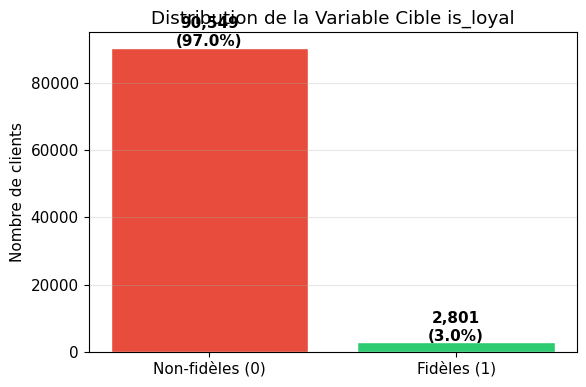

In [5]:
# CELLULE 3 — Vérification de la Variable Cible

# is_loyal = 1 si le client a fait > 1 commande, sinon 0
# C'est notre variable à prédire (classification binaire)

print("\n=== VARIABLE CIBLE : is_loyal ===")
vc = ca['is_loyal'].value_counts()
print(f"  Classe 0 (one-shot)  : {vc[0]:,} clients ({vc[0]/len(ca)*100:.1f}%)")
print(f"  Classe 1 (fidèles)   : {vc[1]:,} clients ({vc[1]/len(ca)*100:.1f}%)")
print(f"\n  ⚠ Dataset DÉSÉQUILIBRÉ — le modèle devra gérer ce déséquilibre")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Non-fidèles (0)', 'Fidèles (1)'], [vc[0], vc[1]],
       color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax.set_title('Distribution de la Variable Cible is_loyal')
ax.set_ylabel('Nombre de clients')
for i, v in enumerate([vc[0], vc[1]]):
    ax.text(i, v + 500, f'{v:,}\n({v/len(ca)*100:.1f}%)', ha='center', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('phase7_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# CELLULE 4 — Sélection des Features de Base

# On sélectionne les colonnes pertinentes pour le ML
# Encodage de l'état géographique (variable catégorielle -> numérique)
le = LabelEncoder()
ca['state_encoded'] = le.fit_transform(ca['customer_state'].astype(str))

FEATURES_BASE = [
    'recency_days',        # R — Récence (jours depuis dernier achat)
    'total_spent',         # M — Montant total dépensé
    'is_high_value',       # 1 si dépense >= médiane
    'state_encoded',       # Etat brésilien encodé numériquement
]

# Garder seulement les colonnes qui existent
FEATURES_BASE = [f for f in FEATURES_BASE if f in ca.columns]
print(f"✓ {len(FEATURES_BASE)} features sélectionnées : {FEATURES_BASE}")

TARGET = 'is_loyal'

✓ 4 features sélectionnées : ['recency_days', 'total_spent', 'is_high_value', 'state_encoded']


In [7]:
# CELLULE 5 — Création de Nouvelles Features (Feature Engineering)

# Le Feature Engineering consiste à générer des variables plus informatives à partir des données existantes afin
# d'améliorer les performances des futurs modèles ML.

# Log-transformation des variables très asymétriques
ca['log_total_spent']      = np.log1p(ca['total_spent'])       # log(1 + x) évite log(0)
ca['log_recency']          = np.log1p(ca['recency_days'])

print("✓ Nouvelles features créées :")
new_features = ['log_total_spent', 'log_recency']
for f in new_features:
    print(f"  + {f:25} | mean={ca[f].mean():.3f} | std={ca[f].std():.3f}")

✓ Nouvelles features créées :
  + log_total_spent           | mean=4.729 | std=0.809
  + log_recency               | mean=5.166 | std=0.933


In [8]:
# CELLULE 6 — Liste Finale des Features ML

FEATURES_ML = FEATURES_BASE + new_features
# Éviter nb_orders (trop corrélé à is_loyal par construction)
print(f"\n✓ Features ML finales ({len(FEATURES_ML)}) :")
for i, f in enumerate(FEATURES_ML, 1):
    print(f"  {i:2}. {f}")


✓ Features ML finales (6) :
   1. recency_days
   2. total_spent
   3. is_high_value
   4. state_encoded
   5. log_total_spent
   6. log_recency


In [9]:
# CELLULE 7 — Vérification des Valeurs Manquantes et Infinies

X = ca[FEATURES_ML].copy()
y = ca[TARGET].copy()

# Remplacer les inf par NaN puis imputer par médiane
X.replace([np.inf, -np.inf], np.nan, inplace=True)

missing = X.isnull().sum()
if missing.sum() > 0:
    print("⚠ Valeurs manquantes détectées :")
    print(missing[missing > 0])
    X.fillna(X.median(), inplace=True)
    print("✓ Imputées par la médiane")
else:
    print("✓ Aucune valeur manquante")

print(f"\n✓ Dimensions du dataset ML : X={X.shape}, y={y.shape}")

✓ Aucune valeur manquante

✓ Dimensions du dataset ML : X=(93350, 6), y=(93350,)


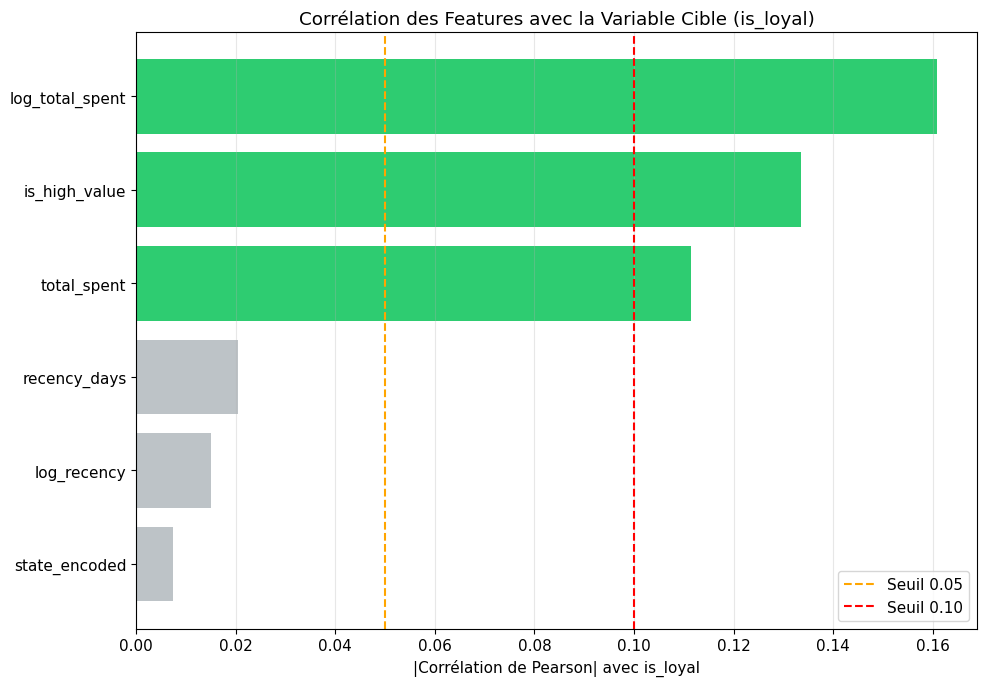


=== TOP 10 Features les plus corrélées avec is_loyal ===
log_total_spent    0.1609
is_high_value      0.1336
total_spent        0.1114
recency_days       0.0204
log_recency        0.0150
state_encoded      0.0074
dtype: float64


In [10]:
# CELLULE 8 — Analyse de la Corrélation des Features avec la Cible

# Corrélation de Pearson avec is_loyal
corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ecc71' if v > 0.1 else '#3498db' if v > 0.05 else '#bdc3c7'
          for v in corr_with_target.values]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors[::-1])
ax.set_xlabel('|Corrélation de Pearson| avec is_loyal')
ax.set_title('Corrélation des Features avec la Variable Cible (is_loyal)')
ax.axvline(x=0.05, color='orange', linestyle='--', label='Seuil 0.05')
ax.axvline(x=0.10, color='red',    linestyle='--', label='Seuil 0.10')
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('phase7_correlation_target.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TOP 10 Features les plus corrélées avec is_loyal ===")
print(corr_with_target.head(10).round(4))

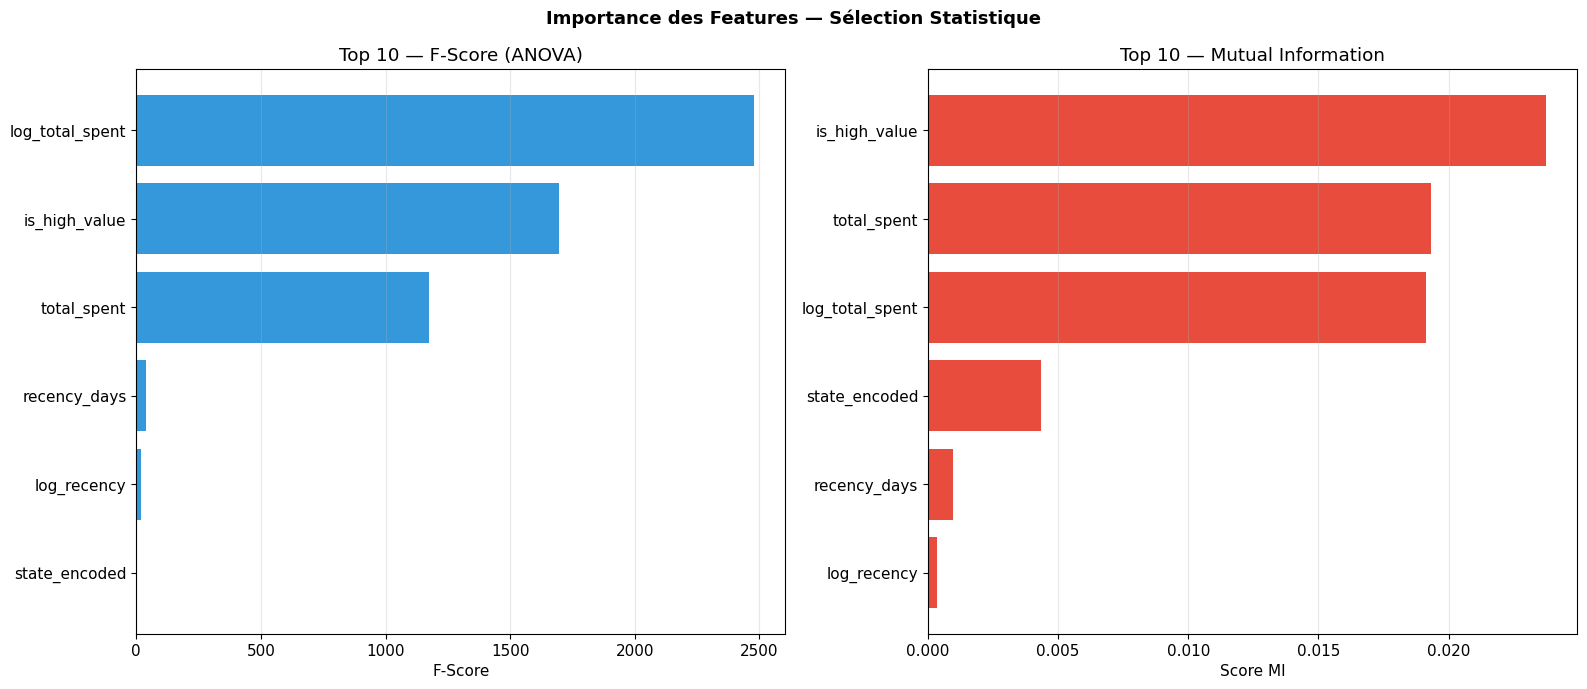

In [11]:
# CELLULE 9 — Sélection par SelectKBest (F-Score et Mutual Info)

# Sélection statistique des variables.
# Deux méthodes complémentaires sont utilisées :
# - F-Score (relation linéaire avec la cible)
# - Mutual Information (relations non linéaires)
# Les variables les plus pertinentes seront conservées.

# F-Score (test ANOVA univarié)
selector_f = SelectKBest(f_classif, k='all')
selector_f.fit(X, y)
f_scores = pd.Series(selector_f.scores_, index=X.columns).sort_values(ascending=False)

# Mutual Information (non linéaire)
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(f_scores.index[:10][::-1], f_scores.values[:10][::-1], color='#3498db')
axes[0].set_title('Top 10 — F-Score (ANOVA)')
axes[0].set_xlabel('F-Score')
axes[0].grid(True, axis='x', alpha=0.3)

axes[1].barh(mi_series.index[:10][::-1], mi_series.values[:10][::-1], color='#e74c3c')
axes[1].set_title('Top 10 — Mutual Information')
axes[1].set_xlabel('Score MI')
axes[1].grid(True, axis='x', alpha=0.3)

plt.suptitle('Importance des Features — Sélection Statistique', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase7_feature_importance_stats.png', dpi=150, bbox_inches='tight')
plt.show()

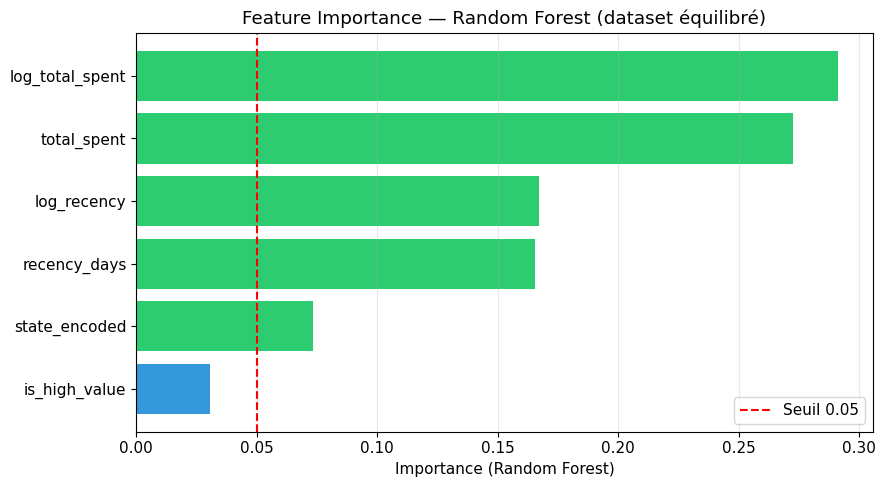


=== Importance RF des features ===
log_total_spent    0.2911
total_spent        0.2726
log_recency        0.1670
recency_days       0.1654
state_encoded      0.0734
is_high_value      0.0306
dtype: float64


In [12]:
# CELLULE 10 — Sélection par Random Forest (Feature Importance)

# Importance des variables par Random Forest.
# Un modèle Random Forest est entraîné sur un dataset équilibré afin d'éviter le biais dû au déséquilibre
# entre clients fidèles et non fidèles.
from sklearn.utils import resample

# Sous-échantillonnage pour équilibrer les classes (stratified)
ca_majority  = ca[ca['is_loyal'] == 0].sample(n=5000, random_state=42)
ca_minority  = ca[ca['is_loyal'] == 1]
ca_balanced  = pd.concat([ca_majority, ca_minority])

X_bal = ca_balanced[FEATURES_ML].copy()
X_bal.replace([np.inf, -np.inf], np.nan, inplace=True)
X_bal.fillna(X_bal.median(), inplace=True)
y_bal = ca_balanced[TARGET]

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_bal, y_bal)

rf_importances = pd.Series(rf_selector.feature_importances_, index=FEATURES_ML).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71' if v > 0.05 else '#3498db' for v in rf_importances.values]
ax.barh(rf_importances.index[::-1], rf_importances.values[::-1], color=colors[::-1])
ax.set_xlabel('Importance (Random Forest)')
ax.set_title('Feature Importance — Random Forest (dataset équilibré)')
ax.axvline(x=0.05, color='red', linestyle='--', label='Seuil 0.05')
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('phase7_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Importance RF des features ===")
print(rf_importances.round(4))

In [13]:
# CELLULE 11 — Sélection Finale des Features ML

# Construction de la liste finale des variables.
# Une feature est retenue si elle est jugée importante par au moins une des méthodes précédentes
# (Corrélation, Mutual Information ou Random Forest).
# On garde les features importantes selon au moins 2 méthodes

top_corr = set(corr_with_target[corr_with_target > 0.03].index)
top_mi   = set(mi_series.head(12).index)
top_rf   = set(rf_importances[rf_importances > 0.02].index)

FEATURES_FINAL = list(top_corr | top_mi | top_rf)
FEATURES_FINAL = [f for f in FEATURES_FINAL if f in X.columns]

print(f"\n✓ Features finales retenues ({len(FEATURES_FINAL)}) :")
for f in sorted(FEATURES_FINAL):
    in_corr = "✓" if f in top_corr else " "
    in_mi   = "✓" if f in top_mi   else " "
    in_rf   = "✓" if f in top_rf   else " "
    print(f"  [{in_corr}corr] [{in_mi}MI] [{in_rf}RF]  {f}")


✓ Features finales retenues (6) :
  [✓corr] [✓MI] [✓RF]  is_high_value
  [ corr] [✓MI] [✓RF]  log_recency
  [✓corr] [✓MI] [✓RF]  log_total_spent
  [ corr] [✓MI] [✓RF]  recency_days
  [ corr] [✓MI] [✓RF]  state_encoded
  [✓corr] [✓MI] [✓RF]  total_spent



✓ Normalisation StandardScaler appliquée
  Moyenne (doit être ≈0) : 0.000000
  Écart-type (doit être ≈1) : 1.0000


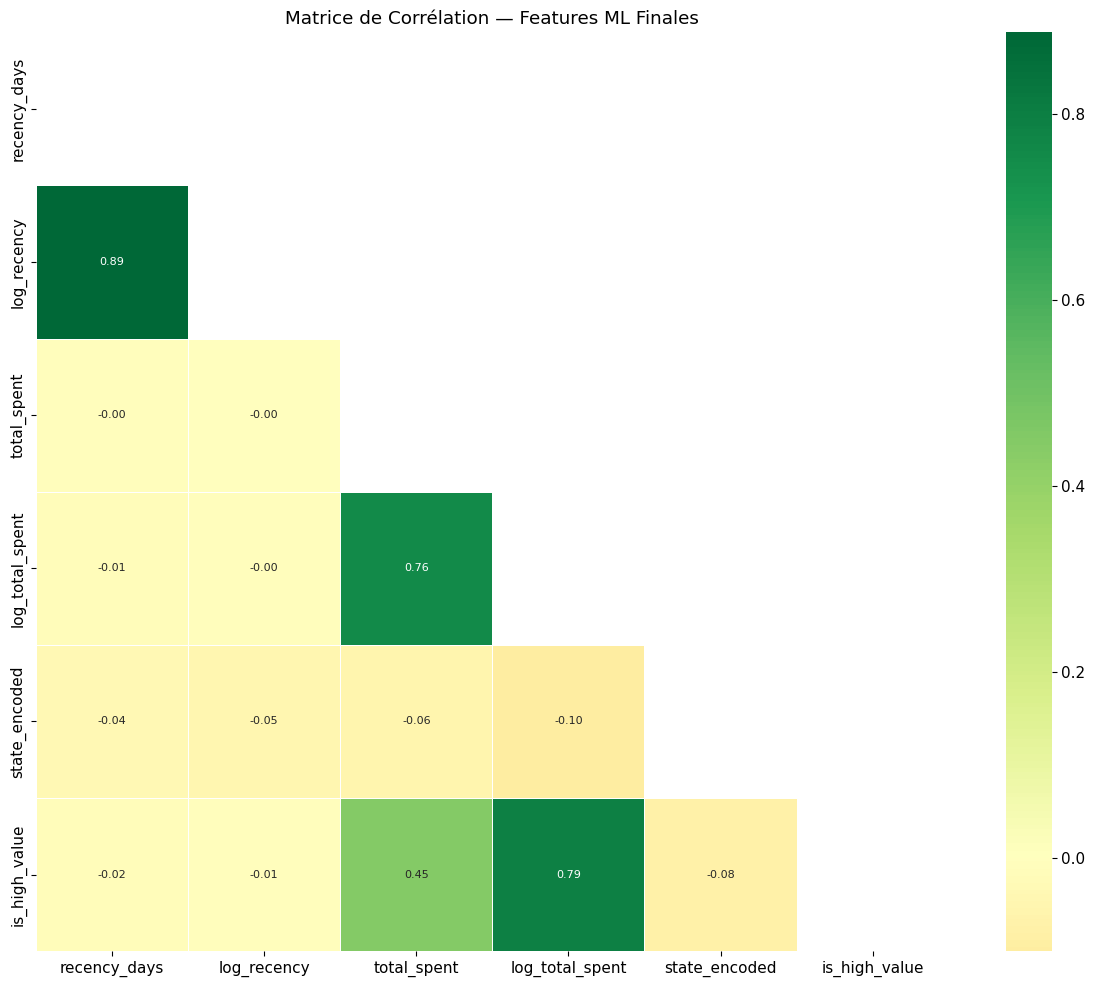

In [14]:
# CELLULE 12 — Normalisation du Dataset ML Final

X_final = X[FEATURES_FINAL].copy()

# StandardScaler : moyenne=0, écart-type=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES_FINAL, index=X_final.index)

print("\n✓ Normalisation StandardScaler appliquée")
print(f"  Moyenne (doit être ≈0) : {X_scaled_df.mean().mean():.6f}")
print(f"  Écart-type (doit être ≈1) : {X_scaled_df.std().mean():.4f}")

# Heatmap de corrélation entre les features finales
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = X_final.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Matrice de Corrélation — Features ML Finales')
plt.tight_layout()
plt.savefig('phase7_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# CELLULE 13 — Export du Dataset ML

# Sauvegarde des datasets Machine Learning.
# Deux versions sont générées :
# - dataset_ml.csv          : valeurs originales.
# - dataset_ml_scaled.csv   : variables normalisées.
# Ces fichiers seront utilisés dans la Phase 8 (Modélisation Prédictive).

# Dataset ML complet (non normalisé, pour SHAP Phase 10)
dataset_ml = X_final.copy()
dataset_ml['is_loyal'] = y.values
dataset_ml.to_csv('dataset_ml.csv', index=False)

# Dataset normalisé
dataset_ml_scaled = X_scaled_df.copy()
dataset_ml_scaled['is_loyal'] = y.values
dataset_ml_scaled.to_csv('dataset_ml_scaled.csv', index=False)

# Sauvegarder la liste des features finales
pd.Series(FEATURES_FINAL).to_csv('features_final_list.csv', index=False, header=['feature'])

# Copie sur Drive
for fname in ['dataset_ml.csv', 'dataset_ml_scaled.csv', 'features_final_list.csv']:
    shutil.copy(fname, f'/content/drive/MyDrive/DDDM_Projet/{fname}')

print("✓ Exports :")
print("  dataset_ml.csv             — features non normalisées + cible")
print("  dataset_ml_scaled.csv      — features normalisées + cible")
print("  features_final_list.csv    — liste des features retenues")

✓ Exports :
  dataset_ml.csv             — features non normalisées + cible
  dataset_ml_scaled.csv      — features normalisées + cible
  features_final_list.csv    — liste des features retenues


In [16]:
# CELLULE 14 — Synthèse Phase 7

print("\n" + "=" * 70)
print(" SYNTHÈSE PHASE 7 : FEATURE ENGINEERING ML")
print("=" * 70)
print(f"""
VARIABLE CIBLE
  is_loyal : 1 (fidèle) = {y.sum():,} clients ({y.mean()*100:.1f}%)
             0 (one-shot) = {(1-y).sum():,} clients ({(1-y).mean()*100:.1f}%)
  ⚠ Dataset déséquilibré → gérer avec class_weight ou SMOTE en Phase 8

FEATURES
  Features de base    : {len(FEATURES_BASE)}
  Nouvelles features  : {len(new_features)}
  Features ML finales : {len(FEATURES_FINAL)}

PREPROCESSING
  Normalisation       : StandardScaler (μ=0, σ=1)
  Valeurs manquantes  : Imputées par médiane
  Valeurs infinies    : Remplacées par NaN puis médiane
""")

graphs = ['phase7_target_distribution.png', 'phase7_correlation_target.png',
          'phase7_feature_importance_stats.png', 'phase7_rf_feature_importance.png',
          'phase7_correlation_heatmap.png']
print(f"Graphiques sauvegardés ({len(graphs)}) :")
for g in graphs:
    print(f"  ✓ {g}")

print("\n✓ Phase 7 terminée — prêt pour Phase 8 (Modélisation Prédictive)")


 SYNTHÈSE PHASE 7 : FEATURE ENGINEERING ML

VARIABLE CIBLE
  is_loyal : 1 (fidèle) = 2,801 clients (3.0%)
             0 (one-shot) = 90,549 clients (97.0%)
  ⚠ Dataset déséquilibré → gérer avec class_weight ou SMOTE en Phase 8

FEATURES
  Features de base    : 4
  Nouvelles features  : 2
  Features ML finales : 6

PREPROCESSING
  Normalisation       : StandardScaler (μ=0, σ=1)
  Valeurs manquantes  : Imputées par médiane
  Valeurs infinies    : Remplacées par NaN puis médiane

Graphiques sauvegardés (5) :
  ✓ phase7_target_distribution.png
  ✓ phase7_correlation_target.png
  ✓ phase7_feature_importance_stats.png
  ✓ phase7_rf_feature_importance.png
  ✓ phase7_correlation_heatmap.png

✓ Phase 7 terminée — prêt pour Phase 8 (Modélisation Prédictive)
